In [1]:
# library(sceasy)
# library(Seurat)
# library(dplyr)
# library(SeuratDisk)
# library(anndata)

# for (i in 1:10) {
#   file_fold <- paste0("/home/project/11003054/changxu/Projects/DIRAC/Section-2/simulations/sp_multi_omics/sim_", i, "/")
#   out_path <- "/home/project/11003054/changxu/Projects/DIRAC/Section-2"
  
#   data_name <- "sim"
#   methods <- "Seurat"
#   save_path <- file.path(out_path, "Results", paste0(data_name, "_", i, "_", methods))
#     if (!dir.exists(save_path)) {
#     dir.create(save_path, recursive = TRUE) 
#   }
    
#   # Convert .h5ad → .h5seurat
#   Convert(paste0(file_fold, data_name, "_RNA.h5ad"), dest = "h5seurat", overwrite = TRUE)
#   Convert(paste0(file_fold, data_name, "_ADT.h5ad"), dest = "h5seurat", overwrite = TRUE)
    
#   # Load data (skip metadata to avoid errors)
#   rna <- LoadH5Seurat(paste0(file_fold, data_name, "_RNA.h5seurat"), meta.data = FALSE)
#   adt <- LoadH5Seurat(paste0(file_fold, data_name, "_ADT.h5seurat"), meta.data = FALSE)

#   # Rebuild Seurat object (ensure counts are properly formatted)
#   rna <- CreateSeuratObject(counts = rna@assays$RNA@counts, project = "rna")
  
#   # Standard workflow
#   rna <- NormalizeData(rna, normalization.method = "LogNormalize", scale.factor = 10000)
#   rna <- FindVariableFeatures(rna, selection.method = "vst", nfeatures = 1500)
#   rna <- ScaleData(rna, features = rownames(rna))
#   rna <- RunPCA(rna, features = VariableFeatures(rna))
  
#   # Check PCA dimensions and adjust dims accordingly
#   max_pcs <- ncol(rna@reductions$pca@cell.embeddings)
#   if (max_pcs < 100) {
#     message("Only ", max_pcs, " PCs computed. Adjusting dims.")
#     rna <- FindNeighbors(rna, dims = 1:max_pcs)
#     rna <- RunUMAP(rna, dims = 1:max_pcs)
#   } else {
#     rna <- FindNeighbors(rna, dims = 1:100)
#     rna <- RunUMAP(rna, dims = 1:100)
#   }
#   # Clustering and visualization
#   rna <- FindClusters(rna, resolution = 1.09)
#   p_rna <- DimPlot(rna, reduction = "umap", label = TRUE)
#   # ggsave(file.path(save_path, "rna_umap.png"), p_rna, width = 8, height = 6)
#   write.csv(rna@meta.data, file.path(save_path, "rna_metadata.csv"))

#   adt <- CreateSeuratObject(counts = adt@assays$RNA@counts, project = "adt")
#   adt <- NormalizeData(adt, normalization.method = "LogNormalize", scale.factor = 10000)
#   adt <- FindVariableFeatures(adt, selection.method = "vst", nfeatures = 80)
#   all.genes <- rownames(adt)
#   adt <- ScaleData(adt, features = all.genes)
#   adt <- RunPCA(adt, features = VariableFeatures(object = adt))
#   adt <- FindNeighbors(adt, dims = 1:18)
#   adt <- FindClusters(adt, resolution = 1.0) 
#   adt <- RunUMAP(adt, dims = 1:10)
#   DimPlot(adt, reduction = "umap", label = T)
#   # ggsave(file.path(save_path, "adt_umap.png"), p_adt, width = 8, height = 6)
#   write.csv(adt@meta.data, file.path(save_path, "adt_metadata.csv")) 

#   rna[["ADT"]] <- CreateAssayObject(counts = adt@assays$RNA@counts)

#   DefaultAssay(rna) <- 'RNA'
#   rna <- NormalizeData(rna) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA()

#   DefaultAssay(rna) <- 'ADT'
#   # we will use all ADT features for dimensional reduction
#   # we set a dimensional reduction name to avoid overwriting the 
#   VariableFeatures(rna) <- rownames(rna[["ADT"]])
#   rna <- NormalizeData(rna, normalization.method = 'CLR', margin = 2) %>% 
#   ScaleData() %>% RunPCA(reduction.name = 'apca')

#   rna <- FindMultiModalNeighbors(
#     rna, reduction.list = list("pca", "apca"), 
#     dims.list = list(1:30, 1:18), modality.weight.name = "RNA.weight"
#   )

#   rna <- RunUMAP(rna, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
#   rna <- FindClusters(rna, graph.name = "wsnn", algorithm = 3, resolution = 0.7, verbose = FALSE)
#   DimPlot(rna, reduction = 'wnn.umap', label = TRUE, repel = TRUE, label.size = 2.5)

#   write.csv(rna@meta.data, file.path(save_path, paste0(data_name, "_", i, "_", methods, "csv")))

# }

Loading required package: reticulate

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Registered S3 method overwritten by 'SeuratDisk':
  method            from  
  as.sparse.H5Group Seurat


Attaching package: ‘anndata’


The following object is masked from ‘package:SeuratObject’:

    Layers


Warning message:
“Unknown file type: h5ad”
Warning message:
“'assay' not set, setting to 'RNA'”
Creating h5Seurat file for version 3.1.5.9900

Adding X as scale.data

Adding X as data

Adding X as counts

Adding meta.features from var

Adding spatial as cell embeddings for spatial

Warning message:
“Unknown file type: h5ad”
Warning message:
“'assay' not set, setting 

In [3]:
library(sceasy)
library(Seurat)
library(dplyr)
library(SeuratDisk)
library(anndata)

for (i in 1:10) {
  file_fold <- paste0("/home/project/11003054/changxu/Projects/DIRAC/Section-2/simulations/sp_multi_omics/sim_", i, "/")
  out_path <- "/home/project/11003054/changxu/Projects/DIRAC/Section-2"
  
  data_name <- "sim"
  methods <- "Seurat"
  save_path <- file.path(out_path, "Results", paste0(data_name, "_", i, "_", methods))
  if (!dir.exists(save_path)) {
    dir.create(save_path, recursive = TRUE) 
  }
    
  # Convert .h5ad → .h5seurat
  Convert(paste0(file_fold, data_name, "_RNA.h5ad"), dest = "h5seurat", overwrite = TRUE)
  Convert(paste0(file_fold, data_name, "_ADT.h5ad"), dest = "h5seurat", overwrite = TRUE)
    
  # Load data (skip metadata to avoid errors)
  rna <- LoadH5Seurat(paste0(file_fold, data_name, "_RNA.h5seurat"), meta.data = FALSE)
  adt <- LoadH5Seurat(paste0(file_fold, data_name, "_ADT.h5seurat"), meta.data = FALSE)

  # Rebuild Seurat object using GetAssayData()
  rna_counts <- GetAssayData(rna, assay = "RNA", slot = "counts")
  rna <- CreateSeuratObject(counts = rna_counts, project = "rna")
  
  # Standard workflow
  rna <- NormalizeData(rna, normalization.method = "LogNormalize", scale.factor = 10000)
  rna <- FindVariableFeatures(rna, selection.method = "vst", nfeatures = 500)
  rna <- ScaleData(rna, features = rownames(rna))
  rna <- RunPCA(rna, features = VariableFeatures(rna))
  
  # Check PCA dimensions and adjust dims accordingly
  max_pcs <- ncol(rna@reductions$pca@cell.embeddings)
  if (max_pcs < 100) {
    message("Only ", max_pcs, " PCs computed. Adjusting dims.")
    rna <- FindNeighbors(rna, dims = 1:max_pcs)
    rna <- RunUMAP(rna, dims = 1:max_pcs)
  } else {
    rna <- FindNeighbors(rna, dims = 1:100)
    rna <- RunUMAP(rna, dims = 1:100)
  }
  
  # Clustering and visualization
  rna <- FindClusters(rna, resolution = 1.09)
  p_rna <- DimPlot(rna, reduction = "umap", label = TRUE)
  write.csv(rna@meta.data, file.path(save_path, "rna_metadata.csv"))

  adt_counts <- GetAssayData(adt, assay = "RNA", slot = "counts")
  adt <- CreateSeuratObject(counts = adt_counts, project = "adt")
  adt <- NormalizeData(adt, normalization.method = "LogNormalize", scale.factor = 10000)
  adt <- FindVariableFeatures(adt, selection.method = "vst", nfeatures = 50)
  all.genes <- rownames(adt)
  adt <- ScaleData(adt, features = all.genes)
  adt <- RunPCA(adt, features = VariableFeatures(object = adt))
  adt <- FindNeighbors(adt, dims = 1:18)
  adt <- FindClusters(adt, resolution = 1.0) 
  adt <- RunUMAP(adt, dims = 1:10)
  DimPlot(adt, reduction = "umap", label = T)
  write.csv(adt@meta.data, file.path(save_path, "adt_metadata.csv")) 

  # Add ADT data to RNA object
  rna[["ADT"]] <- CreateAssayObject(counts = GetAssayData(adt, assay = "RNA", slot = "counts"))

  DefaultAssay(rna) <- 'RNA'
  rna <- NormalizeData(rna) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA()

  DefaultAssay(rna) <- 'ADT'
  VariableFeatures(rna) <- rownames(rna[["ADT"]])
  rna <- NormalizeData(rna, normalization.method = 'CLR', margin = 2) %>% 
    ScaleData() %>% RunPCA(reduction.name = 'apca')

  rna <- FindMultiModalNeighbors(
    rna, reduction.list = list("pca", "apca"), 
    dims.list = list(1:30, 1:18), modality.weight.name = "RNA.weight"
  )

  rna <- RunUMAP(rna, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
  rna <- FindClusters(rna, graph.name = "wsnn", algorithm = 3, resolution = 0.7, verbose = FALSE)
  DimPlot(rna, reduction = 'wnn.umap', label = TRUE, repel = TRUE, label.size = 2.5)

  write.csv(rna@meta.data, file.path(save_path, paste0(data_name, "_", i, "_", methods, ".csv")))
}

Warning message:
“Unknown file type: h5ad”
Warning message:
“'assay' not set, setting to 'RNA'”
Creating h5Seurat file for version 3.1.5.9900

Adding X as scale.data

Adding X as data

Adding X as counts

Adding meta.features from var

Adding spatial as cell embeddings for spatial

Warning message:
“Unknown file type: h5ad”
Warning message:
“'assay' not set, setting to 'RNA'”
Creating h5Seurat file for version 3.1.5.9900

Adding X as scale.data

Adding X as data

Adding X as counts

Adding meta.features from var

Adding spatial as cell embeddings for spatial

Validating h5Seurat file

Initializing RNA with data

Adding counts for RNA

Adding scale.data for RNA

Adding feature-level metadata for RNA

Adding reduction spatial

Adding cell embeddings for spatial

Adding miscellaneous information for spatial

Adding command information

Adding miscellaneous information

Adding tool-specific results

Validating h5Seurat file

Initializing RNA with data

Adding counts for RNA

Adding scale.d

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4096
Number of edges: 218586

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8716
Number of communities: 22
Elapsed time: 0 seconds


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“did not converge--results might be invalid!; try increasing work or maxit”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
PC_ 1 
Po

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4096
Number of edges: 148739

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8854
Number of communities: 18
Elapsed time: 0 seconds


11:44:57 UMAP embedding parameters a = 0.9922 b = 1.112

11:44:57 Read 4096 rows and found 10 numeric columns

11:44:57 Using Annoy for neighbor search, n_neighbors = 30

11:44:57 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

11:44:58 Writing NN index file to temp file /tmp/RtmprnKL8r/file2064669e8903

11:44:58 Searching Annoy index using 1 thread, search_k = 3000

11:44:59 Annoy recall = 100%

11:45:00 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

11:45:01 Initializing from normalized Laplacian + noise (using RSpectra)

11:45:01 Commencing optimization for 500 epochs, with 164288 positive edges

11:45:01 Using rng type: pcg

11:45:06 Optimization finished

Normalizing layer: counts

Finding variable features for layer count

...

12:00:52 UMAP embedding parameters a = 0.9922 b = 1.112

12:00:52 Read 4096 rows and found 10 numeric columns

12:00:52 Using Annoy for neighbor search, n_neighbors = 30

12:00:52 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:00:52 Writing NN index file to temp file /tmp/RtmprnKL8r/file2064664acdccb

12:00:52 Searching Annoy index using 1 thread, search_k = 3000

12:00:54 Annoy recall = 100%

12:00:54 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:00:55 Initializing from normalized Laplacian + noise (using RSpectra)

12:00:55 Commencing optimization for 500 epochs, with 166240 positive edges

12:00:55 Using rng type: pcg

12:01:00 Optimization finished

Normalizing layer: counts

Finding variable features for layer coun

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4096
Number of edges: 201185

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8872
Number of communities: 22
Elapsed time: 0 seconds


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“did not converge--results might be invalid!; try increasing work or maxit”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
PC_ 1 
Po

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4096
Number of edges: 143269

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8797
Number of communities: 19
Elapsed time: 0 seconds


12:08:28 UMAP embedding parameters a = 0.9922 b = 1.112

12:08:28 Read 4096 rows and found 10 numeric columns

12:08:28 Using Annoy for neighbor search, n_neighbors = 30

12:08:28 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

12:08:28 Writing NN index file to temp file /tmp/RtmprnKL8r/file206466fdab0c1

12:08:28 Searching Annoy index using 1 thread, search_k = 3000

12:08:30 Annoy recall = 100%

12:08:30 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

12:08:31 Initializing from normalized Laplacian + noise (using RSpectra)

12:08:31 Commencing optimization for 500 epochs, with 163360 positive edges

12:08:31 Using rng type: pcg

12:08:36 Optimization finished

Normalizing layer: counts

Finding variable features for layer coun

In [2]:
library(sceasy)
library(Seurat)
library(dplyr)
library(SeuratDisk)
library(anndata)
library(ggplot2) 

for (i in 1:10) {
  file_fold <- paste0("/home/project/11003054/changxu/Projects/DIRAC/Section-2/simulations/sp_multi_omics/sim_", i, "/")
  out_path <- "/home/project/11003054/changxu/Projects/DIRAC/Section-2"
  
  data_name <- "sim"
  methods <- "Seurat"
  save_path <- file.path(out_path, "Results", paste0(data_name, "_", i, "_", methods))
  if (!dir.exists(save_path)) {
    dir.create(save_path, recursive = TRUE) 
  }
    
  # Convert .h5ad → .h5seurat
  Convert(paste0(file_fold, data_name, "_RNA.h5ad"), dest = "h5seurat", overwrite = TRUE)
  Convert(paste0(file_fold, data_name, "_ADT.h5ad"), dest = "h5seurat", overwrite = TRUE)
    
  # Load data (skip metadata to avoid errors)
  rna <- LoadH5Seurat(paste0(file_fold, data_name, "_RNA.h5seurat"), meta.data = FALSE)
  adt <- LoadH5Seurat(paste0(file_fold, data_name, "_ADT.h5seurat"), meta.data = FALSE)

  # Rebuild Seurat object using GetAssayData()
  rna_counts <- GetAssayData(rna, assay = "RNA", slot = "counts")
  rna <- CreateSeuratObject(counts = rna_counts, project = "rna")
  
  # Standard workflow
  rna <- NormalizeData(rna, normalization.method = "LogNormalize", scale.factor = 10000)
  rna <- FindVariableFeatures(rna, selection.method = "vst", nfeatures = 500)
  rna <- ScaleData(rna, features = rownames(rna))
  rna <- RunPCA(rna, features = VariableFeatures(rna))
  
  # Check PCA dimensions and adjust dims accordingly
  max_pcs <- ncol(rna@reductions$pca@cell.embeddings)
  if (max_pcs < 100) {
    message("Only ", max_pcs, " PCs computed. Adjusting dims.")
    rna <- FindNeighbors(rna, dims = 1:max_pcs)
    rna <- RunUMAP(rna, dims = 1:max_pcs)
  } else {
    rna <- FindNeighbors(rna, dims = 1:100)
    rna <- RunUMAP(rna, dims = 1:100)
  }
  
  rna <- FindClusters(rna, resolution = 1.09)
  p_rna <- DimPlot(rna, reduction = "umap", label = TRUE)
  ggsave(file.path(save_path, "rna_umap.png"), p_rna, width = 8, height = 6) 
  write.csv(rna@meta.data, file.path(save_path, "rna_metadata.csv"))

  adt_counts <- GetAssayData(adt, assay = "RNA", slot = "counts")
  adt <- CreateSeuratObject(counts = adt_counts, project = "adt")
  adt <- NormalizeData(adt, normalization.method = "LogNormalize", scale.factor = 10000)
  adt <- FindVariableFeatures(adt, selection.method = "vst", nfeatures = 50)
  all.genes <- rownames(adt)
  adt <- ScaleData(adt, features = all.genes)
  adt <- RunPCA(adt, features = VariableFeatures(object = adt))
  adt <- FindNeighbors(adt, dims = 1:18)
  adt <- FindClusters(adt, resolution = 1.0) 
  adt <- RunUMAP(adt, dims = 1:10)
  p_adt <- DimPlot(adt, reduction = "umap", label = TRUE)
  ggsave(file.path(save_path, "adt_umap.png"), p_adt, width = 8, height = 6)
  write.csv(adt@meta.data, file.path(save_path, "adt_metadata.csv")) 

  # Add ADT data to RNA object
  rna[["ADT"]] <- CreateAssayObject(counts = GetAssayData(adt, assay = "RNA", slot = "counts"))

  DefaultAssay(rna) <- 'RNA'
  rna <- NormalizeData(rna) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA()

  DefaultAssay(rna) <- 'ADT'
  VariableFeatures(rna) <- rownames(rna[["ADT"]])
  rna <- NormalizeData(rna, normalization.method = 'CLR', margin = 2) %>% 
    ScaleData() %>% RunPCA(reduction.name = 'apca')

  rna <- FindMultiModalNeighbors(
    rna, reduction.list = list("pca", "apca"), 
    dims.list = list(1:30, 1:18), modality.weight.name = "RNA.weight"
  )

  rna <- RunUMAP(rna, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
  
  resolutions <- seq(0.001, 2, by=0.001)
  cluster_counts <- sapply(resolutions, function(res) {
    tmp <- FindClusters(rna, graph.name = "wsnn", algorithm = 3, resolution = res, verbose = FALSE)
    length(unique(tmp@meta.data$seurat_clusters))
  })
  
  exact_match <- which(cluster_counts == 5)
  if(length(exact_match) > 0) {
    best_res <- resolutions[exact_match[1]]
    message(paste0("Using resolution ", best_res, " which gives exactly 5 clusters"))
  } else {
    best_res <- resolutions[which.min(abs(cluster_counts - 5))]
    message(paste0("No exact resolution found for 5 clusters. Using resolution ", best_res, 
                  " which gives ", cluster_counts[which.min(abs(cluster_counts - 5))], " clusters"))
  }
  
  rna <- FindClusters(rna, graph.name = "wsnn", algorithm = 3, resolution = best_res, verbose = FALSE)
  
  p_wnn <- DimPlot(rna, reduction = 'wnn.umap', label = TRUE, repel = TRUE, label.size = 2.5)
  ggsave(file.path(save_path, "wnn_umap.png"), p_wnn, width = 8, height = 6) 
  
  write.csv(rna@meta.data, file.path(save_path, paste0(data_name, "_", i, "_", methods, ".csv")))
  write.csv(data.frame(resolution_used = best_res, n_clusters = length(unique(rna@meta.data$seurat_clusters))),
            file.path(save_path, paste0(data_name, "_", i, "_", methods, "_clustering_info.csv")))
}

Warning message:
“Unknown file type: h5ad”
Warning message:
“'assay' not set, setting to 'RNA'”
Creating h5Seurat file for version 3.1.5.9900

Adding X as scale.data

Adding X as data

Adding X as counts

Adding meta.features from var

Adding spatial as cell embeddings for spatial

Warning message:
“Unknown file type: h5ad”
Warning message:
“'assay' not set, setting to 'RNA'”
Creating h5Seurat file for version 3.1.5.9900

Adding X as scale.data

Adding X as data

Adding X as counts

Adding meta.features from var

Adding spatial as cell embeddings for spatial

Validating h5Seurat file

Initializing RNA with data

Adding counts for RNA

Adding scale.data for RNA

Adding feature-level metadata for RNA

Adding reduction spatial

Adding cell embeddings for spatial

Adding miscellaneous information for spatial

Adding command information

Adding miscellaneous information

Adding tool-specific results

Validating h5Seurat file

Initializing RNA with data

Adding counts for RNA

Adding scale.d

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4096
Number of edges: 218586

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8716
Number of communities: 22
Elapsed time: 0 seconds


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“did not converge--results might be invalid!; try increasing work or maxit”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
PC_ 1 
Po

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4096
Number of edges: 148739

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8854
Number of communities: 18
Elapsed time: 0 seconds


15:03:01 UMAP embedding parameters a = 0.9922 b = 1.112

15:03:01 Read 4096 rows and found 10 numeric columns

15:03:01 Using Annoy for neighbor search, n_neighbors = 30

15:03:01 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:03:01 Writing NN index file to temp file /tmp/Rtmp4LT63e/file3ef16e30e26f41

15:03:01 Searching Annoy index using 1 thread, search_k = 3000

15:03:03 Annoy recall = 100%

15:03:03 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:03:04 Initializing from normalized Laplacian + noise (using RSpectra)

15:03:04 Commencing optimization for 500 epochs, with 164288 positive edges

15:03:04 Using rng type: pcg

15:03:08 Optimization finished

Normalizing layer: counts

Finding variable features for layer cou

...

15:50:55 UMAP embedding parameters a = 0.9922 b = 1.112

15:50:55 Read 4096 rows and found 10 numeric columns

15:50:55 Using Annoy for neighbor search, n_neighbors = 30

15:50:55 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:50:56 Writing NN index file to temp file /tmp/Rtmp4LT63e/file3ef16e668ac933

15:50:56 Searching Annoy index using 1 thread, search_k = 3000

15:50:57 Annoy recall = 100%

15:50:57 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:50:58 Initializing from normalized Laplacian + noise (using RSpectra)

15:50:58 Commencing optimization for 500 epochs, with 164932 positive edges

15:50:58 Using rng type: pcg

15:51:02 Optimization finished

Normalizing layer: counts

Finding variable features for layer cou

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4096
Number of edges: 182036

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9015
Number of communities: 23
Elapsed time: 0 seconds


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“You're computing too large a percentage of total singular values, use a standard svd instead.”
Warning message in svd.function(A = t(x = object), nv = npcs, ...):
“did not converge--results might be invalid!; try increasing work or maxit”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
Warning message:
“Requested number is larger than the number of available items (50). Setting to 50.”
PC_ 1 
Po

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4096
Number of edges: 143643

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8786
Number of communities: 16
Elapsed time: 0 seconds


15:56:16 UMAP embedding parameters a = 0.9922 b = 1.112

15:56:16 Read 4096 rows and found 10 numeric columns

15:56:16 Using Annoy for neighbor search, n_neighbors = 30

15:56:16 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:56:16 Writing NN index file to temp file /tmp/Rtmp4LT63e/file3ef16e90f3784

15:56:16 Searching Annoy index using 1 thread, search_k = 3000

15:56:18 Annoy recall = 100%

15:56:18 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

15:56:19 Initializing from normalized Laplacian + noise (using RSpectra)

15:56:19 Commencing optimization for 500 epochs, with 163012 positive edges

15:56:19 Using rng type: pcg

15:56:23 Optimization finished

Normalizing layer: counts

Finding variable features for layer coun

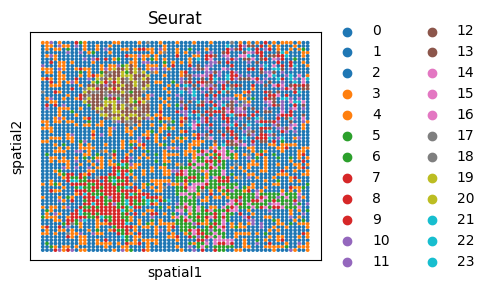

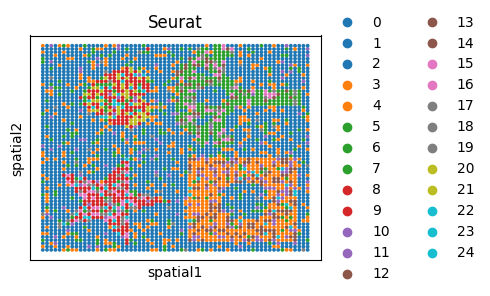

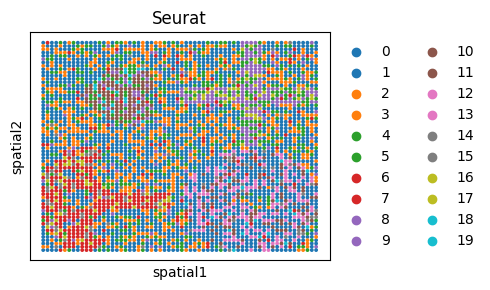

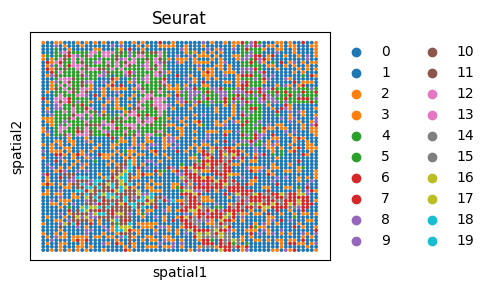

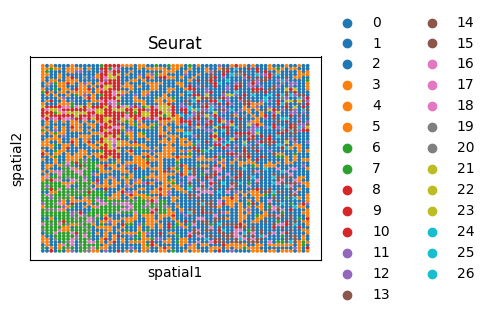

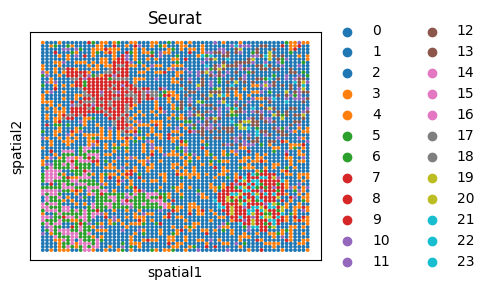

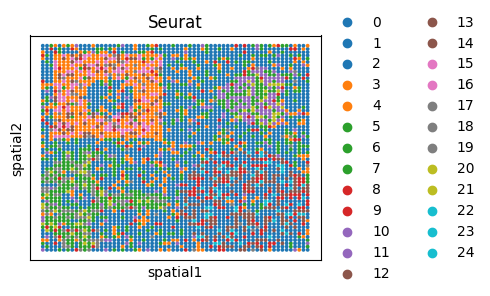

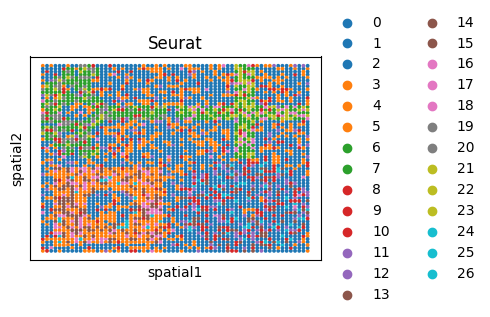

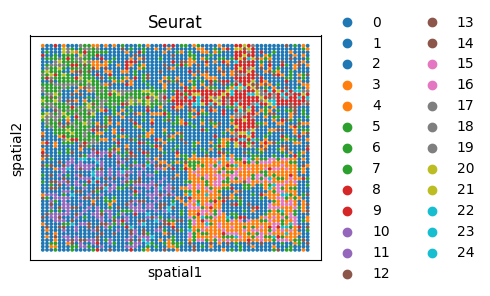

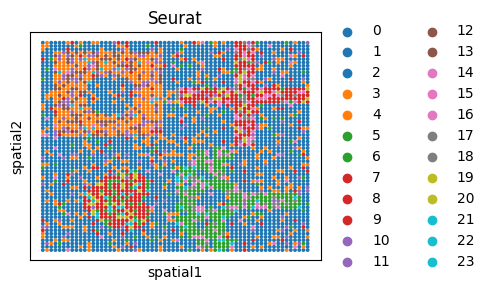

In [1]:
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

for i in range(10):
    data_path = f"/home/project/11003054/changxu/Projects/DIRAC/Section-2/simulations/sp_multi_omics/sim_{i+1}"
    data_name = "sim"
    methods = "Seurat"
    out_path = f"/home/project/11003054/changxu/Projects/DIRAC/Section-2/Results/sim_{i+1}_{methods}"

    adata_RNA = sc.read(os.path.join(data_path, f"{data_name}_RNA.h5ad"))
    df = pd.read_csv(os.path.join(out_path, f"{data_name}_{i+1}_{methods}.csv"))
    adata_RNA.obs[methods] = df.iloc[:, -1].tolist()
    adata_RNA.obs[methods] = adata_RNA.obs[methods].astype('category')

    fig, ax = plt.subplots(figsize=(5, 3))

    sc.pl.embedding(
        adata_RNA,
        basis='spatial',
        color=methods,
        title=methods,
        s=30,
        show=False,
        palette="tab10",
        ax=ax
    )

    plt.tight_layout()
    plt.savefig(os.path.join(out_path, f"{data_name}_{i+1}_{methods}.pdf"), dpi=300)
    plt.show()

In [14]:
library(Seurat)
library(SeuratDisk)

convert_path <- "/home/project/11003054/changxu/Projects/DIRAC/Section-2/simulations/sp_multi_omics_final/sim_2/sim_RNA.h5seurat"

seurat_obj <- LoadH5Seurat(convert_path, meta.data = FALSE)

str(seurat_obj@meta.data)
seurat_obj[["bad_column"]] <- NULL

meta <- seurat_obj@meta.data
bad_cols <- sapply(meta, function(x) !is.atomic(x) || is.list(x))
seurat_obj@meta.data <- meta[ , !bad_cols]

SaveH5Seurat(seurat_obj, filename = "/home/project/11003054/changxu/Projects/DIRAC/Section-2/simulations/sp_multi_omics_final/sim_2/cleaned_sim_RNA.h5Seurat", overwrite = TRUE)

Convert("/home/project/11003054/changxu/Projects/DIRAC/Section-2/simulations/sp_multi_omics_final/sim_2/cleaned_sim_RNA.h5Seurat", dest = "h5ad", overwrite = TRUE)
                   
# Convert(convert_path, dest = "h5ad")

Validating h5Seurat file

Initializing RNA with data

Adding counts for RNA

Adding scale.data for RNA

Adding feature-level metadata for RNA

Adding reduction spatial

Adding cell embeddings for spatial

Adding miscellaneous information for spatial

Adding command information

Adding miscellaneous information

Adding tool-specific results



'data.frame':	4096 obs. of  0 variables


Warning message:
“Cannot find cell-level meta data named  bad_column”
Creating h5Seurat file for version 3.1.5.9900

Adding counts for RNA

Adding data for RNA

Adding scale.data for RNA

No variable features found for RNA

No feature-level metadata found for RNA

Adding cell embeddings for spatial

No loadings for spatial

No projected loadings for spatial

No standard deviations for spatial

No JackStraw data for spatial

Validating h5Seurat file

Adding scale.data from RNA as X

Adding data from RNA as raw

Transfering meta.data to obs

Adding dimensional reduction information for spatial



In [19]:
library(sceasy)
library(Seurat)
library(dplyr)
library(SeuratDisk)
library(anndata)
library(ggplot2) 

for (i in 1:10) {
  file_fold <- paste0("/home/project/11003054/changxu/Projects/DIRAC/Section-2/scMultiSim_data/sim_", i, "/")
  out_path <- "/home/project/11003054/changxu/Projects/DIRAC/Section-2"
  
  data_name <- "sim"
  methods <- "Seurat"
  save_path <- file.path(out_path, "Results", paste0(data_name, "_", i, "_", "scMultiSim", "_", methods))
  if (!dir.exists(save_path)) {
    dir.create(save_path, recursive = TRUE) 
  }
    
  # Convert .h5ad → .h5seurat
  Convert(paste0(file_fold, data_name, "_RNA.h5ad"), dest = "h5seurat", overwrite = TRUE)
  Convert(paste0(file_fold, data_name, "_ATAC.h5ad"), dest = "h5seurat", overwrite = TRUE)
    
  # Load data (skip metadata to avoid errors)
  rna <- LoadH5Seurat(paste0(file_fold, data_name, "_RNA.h5seurat"), meta.data = FALSE)
  adt <- LoadH5Seurat(paste0(file_fold, data_name, "_ATAC.h5seurat"), meta.data = FALSE)

  # Rebuild Seurat object using GetAssayData()
  rna_counts <- GetAssayData(rna, assay = "RNA", slot = "counts")
  rna <- CreateSeuratObject(counts = rna_counts, project = "rna")
  
  # Standard workflow
  rna <- NormalizeData(rna, normalization.method = "LogNormalize", scale.factor = 10000)
  rna <- FindVariableFeatures(rna, selection.method = "vst", nfeatures = 100)
  rna <- ScaleData(rna, features = rownames(rna))
  rna <- RunPCA(rna, features = VariableFeatures(rna))
  
  # Check PCA dimensions and adjust dims accordingly
  max_pcs <- ncol(rna@reductions$pca@cell.embeddings)
  if (max_pcs < 50) {
    message("Only ", max_pcs, " PCs computed. Adjusting dims.")
    rna <- FindNeighbors(rna, dims = 1:max_pcs)
    rna <- RunUMAP(rna, dims = 1:max_pcs)
  } else {
    rna <- FindNeighbors(rna, dims = 1:50)
    rna <- RunUMAP(rna, dims = 1:50)
  }
  
  rna <- FindClusters(rna, resolution = 1.09)
  p_rna <- DimPlot(rna, reduction = "umap", label = TRUE)
  ggsave(file.path(save_path, "rna_umap.png"), p_rna, width = 8, height = 6) 
  write.csv(rna@meta.data, file.path(save_path, "rna_metadata.csv"))

  adt_counts <- GetAssayData(adt, assay = "RNA", slot = "counts")
  adt_counts <- adt_counts[rowSums(adt_counts) > 0, ]
  adt <- CreateSeuratObject(counts = adt_counts, project = "adt")
  adt <- NormalizeData(adt, normalization.method = "LogNormalize", scale.factor = 10000)
  adt <- FindVariableFeatures(adt, selection.method = "vst", nfeatures = 200)
  all.genes <- rownames(adt)
  adt <- ScaleData(adt, features = all.genes)
  adt <- RunPCA(adt, features = VariableFeatures(object = adt))
  adt <- FindNeighbors(adt, dims = 1:18)
  adt <- FindClusters(adt, resolution = 1.0) 
  adt <- RunUMAP(adt, dims = 1:10)
  p_adt <- DimPlot(adt, reduction = "umap", label = TRUE)
  ggsave(file.path(save_path, "adt_umap.png"), p_adt, width = 8, height = 6)
  write.csv(adt@meta.data, file.path(save_path, "adt_metadata.csv")) 

  # Add ADT data to RNA object
  rna[["ADT"]] <- CreateAssayObject(counts = GetAssayData(adt, assay = "RNA", slot = "counts"))

  DefaultAssay(rna) <- 'RNA'
  rna <- NormalizeData(rna) %>% FindVariableFeatures() %>% ScaleData() %>% RunPCA()

  DefaultAssay(rna) <- 'ADT'
  VariableFeatures(rna) <- rownames(rna[["ADT"]])
  rna <- NormalizeData(rna) %>%
    ScaleData() %>% RunPCA(reduction.name = 'apca')

  rna <- FindMultiModalNeighbors(
    rna, reduction.list = list("pca", "apca"), 
    dims.list = list(1:15, 1:20), modality.weight.name = "RNA.weight"
  )

  rna <- RunUMAP(rna, nn.name = "weighted.nn", reduction.name = "wnn.umap", reduction.key = "wnnUMAP_")
  
  resolutions <- seq(0.1, 2, by=0.01)
  cluster_counts <- sapply(resolutions, function(res) {
    tmp <- FindClusters(rna, graph.name = "wsnn", algorithm = 1, resolution = res, verbose = FALSE)
    length(unique(tmp@meta.data$seurat_clusters))
  })
  
  exact_match <- which(cluster_counts == 10)
  if(length(exact_match) > 0) {
    best_res <- resolutions[exact_match[1]]
    message(paste0("Using resolution ", best_res, " which gives exactly 10 clusters"))
  } else {
    best_res <- resolutions[which.min(abs(cluster_counts - 10))]
    message(paste0("No exact resolution found for 10 clusters. Using resolution ", best_res, 
                  " which gives ", cluster_counts[which.min(abs(cluster_counts - 10))], " clusters"))
  }
  
  rna <- FindClusters(rna, graph.name = "wsnn", algorithm = 1, resolution = best_res, verbose = FALSE)
  
  p_wnn <- DimPlot(rna, reduction = 'wnn.umap', label = TRUE, repel = TRUE, label.size = 2.5)
  ggsave(file.path(save_path, "wnn_umap.png"), p_wnn, width = 8, height = 6) 
  
  write.csv(rna@meta.data, file.path(save_path, paste0(data_name, "_", i, "_", methods, ".csv")))
  write.csv(data.frame(resolution_used = best_res, n_clusters = length(unique(rna@meta.data$seurat_clusters))),
            file.path(save_path, paste0(data_name, "_", i, "_", methods, "_clustering_info.csv")))
}

Warning message:
“Unknown file type: h5ad”
Warning message:
“'assay' not set, setting to 'RNA'”
Creating h5Seurat file for version 3.1.5.9900

Adding X as scale.data

Adding X as data

Adding X as counts

Adding meta.features from var

Adding spatial as cell embeddings for spatial

Warning message:
“Unknown file type: h5ad”
Warning message:
“'assay' not set, setting to 'RNA'”
Creating h5Seurat file for version 3.1.5.9900

Adding X as scale.data

Adding X as data

Adding X as counts

Adding meta.features from var

Adding spatial as cell embeddings for spatial

Validating h5Seurat file

Initializing RNA with data

Adding counts for RNA

Adding scale.data for RNA

Adding feature-level metadata for RNA

Adding reduction spatial

Adding cell embeddings for spatial

Adding miscellaneous information for spatial

Adding command information

Adding miscellaneous information

Adding tool-specific results

Validating h5Seurat file

Initializing RNA with data

Adding counts for RNA

Adding scale.d

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 500
Number of edges: 24235

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.5929
Number of communities: 5
Elapsed time: 0 seconds


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  226, 224, 201, 89, 580, 141, 139, 286, 304, 559 
	   28, 528, 502, 485, 127, 198, 506, 412, 66, 83 
	   330, 597, 70, 442, 480, 539, 429, 259, 290, 239 
Negative:  45, 443, 38, 280, 386, 446, 102, 55, 496, 123 
	   266, 282, 481, 423, 211, 202, 291, 210, 558, 503 
	   117, 63, 77, 368, 380, 16, 372, 331, 177, 195 
PC_ 2 
Positive:  195, 532, 165, 62, 274, 380, 450, 275, 16, 207 
	   358, 561, 279, 292, 104, 77, 156, 538, 375, 545 
	   75, 319, 167, 142, 121, 7, 476, 426, 236, 309 
Negative:  486, 291, 105, 596, 481, 210, 368, 63, 503, 338 
	   496, 40, 177, 372, 335, 5, 123, 64, 211, 397 
	   90, 51, 389, 529, 108, 448, 415, 443, 511, 45 
PC_ 3 
Positive:  511, 476, 217, 154, 552, 219, 560, 176, 519, 326 
	   269, 215, 40, 366, 375, 62, 122, 352, 270, 474 
	   202, 512, 123, 102, 322, 130, 175, 331

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 500
Number of edges: 9537

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8654
Number of communities: 12
Elapsed time: 0 seconds


17:43:18 UMAP embedding parameters a = 0.9922 b = 1.112

17:43:18 Read 500 rows and found 10 numeric columns

17:43:18 Using Annoy for neighbor search, n_neighbors = 30

17:43:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:43:18 Writing NN index file to temp file /tmp/Rtmpwq8fNx/file3104a144f0923e

17:43:18 Searching Annoy index using 1 thread, search_k = 3000

17:43:18 Annoy recall = 100%

17:43:19 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

17:43:19 46 smooth knn distance failures

17:43:19 Initializing from normalized Laplacian + noise (using RSpectra)

17:43:19 Commencing optimization for 500 epochs, with 14192 positive edges

17:43:19 Using rng type: pcg

17:43:20 Optimization finished

Normalizing layer: counts


...

17:52:21 UMAP embedding parameters a = 0.9922 b = 1.112

17:52:21 Read 4500 rows and found 10 numeric columns

17:52:21 Using Annoy for neighbor search, n_neighbors = 30

17:52:21 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:52:22 Writing NN index file to temp file /tmp/Rtmpwq8fNx/file3104a13b423ea4

17:52:22 Searching Annoy index using 1 thread, search_k = 3000

17:52:23 Annoy recall = 90.6%

17:52:23 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

17:52:23 484 smooth knn distance failures

17:52:24 Initializing from normalized Laplacian + noise (using RSpectra)

17:52:25 Commencing optimization for 500 epochs, with 173742 positive edges

17:52:25 Using rng type: pcg

17:52:33 Optimization finished

Normalizing layer: cou

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5000
Number of edges: 200719

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7689
Number of communities: 8
Elapsed time: 0 seconds


Warning message:
“Data is of class matrix. Coercing to dgCMatrix.”
Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  279, 214, 68, 532, 537, 111, 195, 119, 42, 265 
	   53, 98, 267, 523, 55, 33, 418, 558, 528, 2 
	   432, 570, 486, 52, 380, 99, 343, 322, 169, 258 
Negative:  593, 514, 475, 599, 250, 381, 210, 202, 442, 27 
	   241, 534, 201, 222, 204, 291, 318, 301, 238, 142 
	   233, 527, 488, 231, 213, 315, 232, 221, 334, 294 
PC_ 2 
Positive:  55, 260, 107, 275, 82, 163, 533, 38, 198, 52 
	   446, 431, 99, 322, 544, 382, 169, 171, 282, 193 
	   423, 112, 299, 213, 329, 584, 400, 528, 521, 86 
Negative:  184, 308, 211, 160, 499, 199, 162, 519, 356, 470 
	   497, 388, 596, 339, 140, 297, 591, 590, 121, 368 
	   194, 144, 289, 209, 272, 445, 178, 196, 371, 252 
PC_ 3 
Positive:  41, 45, 410, 384, 423, 399, 116, 455, 263, 140 
	   481, 5, 460, 397, 240, 535, 329, 395, 542, 555 
	   517, 496, 358, 204, 86, 289, 307

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5000
Number of edges: 202893

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7440
Number of communities: 20
Elapsed time: 0 seconds


17:54:04 UMAP embedding parameters a = 0.9922 b = 1.112

17:54:04 Read 5000 rows and found 10 numeric columns

17:54:04 Using Annoy for neighbor search, n_neighbors = 30

17:54:04 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:54:04 Writing NN index file to temp file /tmp/Rtmpwq8fNx/file3104a169ad4806

17:54:04 Searching Annoy index using 1 thread, search_k = 3000

17:54:05 Annoy recall = 90.24%

17:54:06 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

17:54:06 557 smooth knn distance failures

17:54:06 Initializing from normalized Laplacian + noise (using RSpectra)

17:54:09 Commencing optimization for 500 epochs, with 198368 positive edges

17:54:09 Using rng type: pcg

17:54:16 Optimization finished

Normalizing layer: co